In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from reporting.test import (
    CLASSIFIER_ORDER,
    DEFAULT_ARTIFACTS_DIRECTORY,
    METRIC_DISPLAY_NAMES,
    PRIMARY_TEST_METRIC,
    TestExperimentArtifacts,
    TestStatistics,
    compile_test_statistics,
    display_test_confusion_matrices,
    load_test_experiment_artifacts,
    plot_metric_comparison,
    plot_per_class_metric_heatmap,
    plot_test_seed_metric,
)


In [2]:
# ============================================================================
# Configuration
# ============================================================================

ARTIFACTS_DIRECTORY = DEFAULT_ARTIFACTS_DIRECTORY
DATASET_NAME = "ROSIDS"

# ``None`` means: use the first persisted seed for each classifier.
REPRESENTATIVE_SEED: int | None = None


In [3]:
# ============================================================================
# Small notebook helpers
# ============================================================================


def _metadata_integer(
    metadata: dict[str, object],
    key: str,
) -> int | None:
    """Return a validated integer metadata field."""
    value = metadata.get(key)

    if value is None:
        return None

    if isinstance(value, bool) or not isinstance(value, int):
        raise TypeError(
            f"Metadata field {key!r} must be an integer.",
        )

    return value


def _classifier_label(
    statistics: TestStatistics,
) -> str:
    """Return the display name of the classifier from the summary table."""
    if statistics.summary_table.empty:
        raise ValueError("Test summary table is empty.")

    return str(
        statistics.summary_table["Classifier"].iat[0],
    )

In [4]:
# ============================================================================
# Load persisted ROSIDS test artifacts
# ============================================================================

artifacts_by_classifier: dict[str, TestExperimentArtifacts] = {}

for classifier_name in CLASSIFIER_ORDER:
    artifacts_by_classifier[classifier_name] = load_test_experiment_artifacts(
        dataset_name=DATASET_NAME,
        classifier_name=classifier_name,
        artifacts_directory=ARTIFACTS_DIRECTORY,
    )


statistics_by_classifier: dict[str, TestStatistics] = {
    classifier_name: compile_test_statistics(
        artifacts=artifacts_by_classifier[classifier_name],
        include_validation_comparison=True,
    )
    for classifier_name in CLASSIFIER_ORDER
}


In [5]:
# ============================================================================
# Experiment information
# ============================================================================

experiment_rows: list[dict[str, object]] = []

for classifier_name in CLASSIFIER_ORDER:
    experiment = artifacts_by_classifier[classifier_name]
    metadata = experiment.metadata

    test_row_count = _metadata_integer(
        metadata,
        "test_row_count",
    )
    seed_count = _metadata_integer(
        metadata,
        "seed_count",
    )

    seed_values = tuple(
        sorted(int(seed) for seed in experiment.seed_metrics["seed"].unique())
    )

    experiment_rows.append(
        {
            "Dataset": experiment.dataset_name,
            "Classifier": _classifier_label(
                statistics_by_classifier[classifier_name],
            ),
            "Test observations": (
                test_row_count if test_row_count is not None else pd.NA
            ),
            "Seeds": (seed_count if seed_count is not None else len(seed_values)),
            "Seed values": ", ".join(str(seed) for seed in seed_values),
        },
    )


rosids_experiment_table = pd.DataFrame(
    experiment_rows,
)

display(rosids_experiment_table)


,Dataset,Classifier,Test observations,Seeds,Seed values
0,ROSIDS,Decision Tree,27337,3,"27, 32, 59"
1,ROSIDS,Random Forest,27337,3,"27, 32, 59"
2,ROSIDS,XGBoost,27337,3,"27, 32, 59"


In [6]:
# ============================================================================
# Main final-test metrics
# ============================================================================

rosids_test_summary = pd.concat(
    [
        statistics_by_classifier[classifier_name].summary_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(rosids_test_summary)

,Dataset,Classifier,Seeds,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,ROSIDS,Decision Tree,3,0.973479167429 ± 0.000182902293,0.946500313889 ± 0.000595631756,0.946201922930 ± 0.000154223055,0.946315938629 ± 0.000255890723,0.984711562834 ± 0.000065770696,0.944957539619 ± 0.000403436894,0.961339496273 ± 0.000262731401,0.946201922930 ± 0.000154223055
1,ROSIDS,Random Forest,3,0.977893209448 ± 0.000201469457,0.957140718454 ± 0.000557730552,0.953372557079 ± 0.000501608077,0.955134688621 ± 0.000419155610,0.996097032315 ± 0.000042646023,0.971865382327 ± 0.000139321852,0.967766530361 ± 0.000292307171,0.953372557079 ± 0.000501608077
2,ROSIDS,XGBoost,3,0.977210374218 ± 0.000109741376,0.955199069084 ± 0.000442058249,0.952740797465 ± 0.000452281487,0.953881867779 ± 0.000429487849,0.996584804795 ± 0.000041154510,0.973505115854 ± 0.000362544416,0.966773295712 ± 0.000160592671,0.952740797465 ± 0.000452281487


In [7]:
# ============================================================================
# Selected configurations
# ============================================================================

configuration_tables: list[pd.DataFrame] = []

for classifier_name in CLASSIFIER_ORDER:
    statistics = statistics_by_classifier[classifier_name]

    configuration_table = statistics.selected_configuration_table.copy()

    configuration_table.insert(
        0,
        "Classifier",
        _classifier_label(statistics),
    )

    configuration_tables.append(
        configuration_table,
    )


rosids_selected_configurations = pd.concat(
    configuration_tables,
    ignore_index=True,
).reset_index(drop=True)

display(rosids_selected_configurations)

,Classifier,Configuration ID,criterion,max_depth,min_samples_leaf,min_samples_split,sampler,n_estimators,learning_rate,min_child_weight,subsample
0,Decision Tree,34fdea955c76,entropy,20,1.0,10.0,passthrough,NaN,NaN,NaN,NaN
1,Random Forest,490871c4e714,NaN,20,1.0,5.0,passthrough,200.0,NaN,NaN,NaN
2,XGBoost,17edbfb766e1,NaN,6,NaN,NaN,passthrough,200.0,0.1,1.0,0.8


In [8]:
# ============================================================================
# Test metrics by seed
# ============================================================================

rosids_seed_metrics = pd.concat(
    [
        statistics_by_classifier[classifier_name].seed_metrics_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(rosids_seed_metrics)


,Dataset,Classifier,Seed,Configuration ID,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,ROSIDS,Decision Tree,27,34fdea955c76,0.973479167429,0.946695086249,0.946308433884,0.946464454891,0.984641808913,0.945020135497,0.961340031861,0.946308433884
1,ROSIDS,Decision Tree,32,34fdea955c76,0.973662069722,0.946974176327,0.946025070070,0.946462898156,0.984720428692,0.945326019925,0.961601959471,0.946025070070
2,ROSIDS,Decision Tree,59,34fdea955c76,0.973296265135,0.945831679090,0.946272264837,0.946020462840,0.984772450896,0.944526463436,0.961076497487,0.946272264837
3,ROSIDS,Random Forest,27,490871c4e714,0.978124885686,0.957763674995,0.953630246941,0.955582122991,0.996054126095,0.971841664444,0.968102391472,0.953630246941
4,ROSIDS,Random Forest,32,490871c4e714,0.977795661558,0.956687793269,0.953692942171,0.955070794117,0.996097557561,0.972015040670,0.967627607872,0.953692942171
5,ROSIDS,Random Forest,59,490871c4e714,0.977759081099,0.956970687097,0.952794482124,0.954751148756,0.996139413289,0.971739441868,0.967569591739,0.952794482124
6,ROSIDS,XGBoost,27,17edbfb766e1,0.977100632842,0.954713837506,0.952236995104,0.953385991130,0.996582935123,0.973620064366,0.966613177861,0.952236995104
7,ROSIDS,XGBoost,32,17edbfb766e1,0.977320115594,0.955304468866,0.953111845318,0.954123515296,0.996626862276,0.973796251097,0.966934359028,0.953111845318
8,ROSIDS,XGBoost,59,17edbfb766e1,0.977210374218,0.955578900879,0.952873551973,0.954136096910,0.996544616986,0.973099032098,0.966772350248,0.952873551973


In [9]:
# ============================================================================
# Per-class test metrics
# ============================================================================

rosids_per_class_metrics = pd.concat(
    [
        statistics_by_classifier[classifier_name].per_class_metrics_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(rosids_per_class_metrics)


,Classifier,Class,Support,Precision,Recall,F1
0,Decision Tree,Benign,12503,0.971047976229 ± 0.000111711479,0.975552534059 ± 0.000488690789,0.973294992859 ± 0.000226521945
1,Decision Tree,DoS,6200,0.999408784181 ± 0.000186061890,0.999677419355 ± 0.000000000000,0.999543077944 ± 0.000093060951
2,Decision Tree,Subflood,6013,0.987984374799 ± 0.000345676497,0.975442097677 ± 0.000096017008,0.981673147092 ± 0.000141427915
3,Decision Tree,UnauthPub,1563,0.908198253546 ± 0.001210000866,0.926210279377 ± 0.000369385969,0.917115655927 ± 0.000755794873
4,Decision Tree,UnauthSub,1058,0.865862180689 ± 0.002075284438,0.854127284184 ± 0.001443785663,0.859952819322 ± 0.000865654307
5,Random Forest,Benign,12503,0.973955887886 ± 0.000202900036,0.981044549308 ± 0.000399904023,0.977487329150 ± 0.000210182319
6,Random Forest,DoS,6200,1.000000000000 ± 0.000000000000,0.999677419355 ± 0.000000000000,0.999838683659 ± 0.000000000000
7,Random Forest,Subflood,6013,0.992515481807 ± 0.000194582806,0.977714950940 ± 0.000166306336,0.985059623419 ± 0.000174202534
8,Random Forest,UnauthPub,1563,0.918018535979 ± 0.001701196264,0.943271486458 ± 0.000738771938,0.930472740582 ± 0.000653778341
9,Random Forest,UnauthSub,1058,0.901213686595 ± 0.001190573387,0.865154379332 ± 0.002728498437,0.882815066295 ± 0.001851954854


In [10]:
# ============================================================================
# Validation versus test
# ============================================================================

validation_comparison_tables: list[pd.DataFrame] = []

for classifier_name in CLASSIFIER_ORDER:
    statistics = statistics_by_classifier[classifier_name]
    comparison = statistics.validation_vs_test_table

    if comparison is None:
        continue

    comparison = comparison.copy()

    comparison.insert(
        0,
        "Classifier",
        _classifier_label(statistics),
    )

    validation_comparison_tables.append(
        comparison,
    )


if validation_comparison_tables:
    rosids_validation_vs_test = pd.concat(
        validation_comparison_tables,
        ignore_index=True,
    ).reset_index(drop=True)

    display(rosids_validation_vs_test)
else:
    rosids_validation_vs_test = None


,Classifier,Metric,validation_mean,validation_std,test_mean,test_std,Validation,Test,Test − validation
0,Decision Tree,Accuracy,0.971353,0.000582,0.973479,0.000183,0.971353404546 ± 0.000582467719,0.973479167429 ± 0.000182902293,0.002126
1,Decision Tree,Precision,0.944314,0.001554,0.946500,0.000596,0.944313784791 ± 0.001553859081,0.946500313889 ± 0.000595631756,0.002187
2,Decision Tree,Recall,0.939972,0.001205,0.946202,0.000154,0.939971670555 ± 0.001204954548,0.946201922930 ± 0.000154223055,0.006230
3,Decision Tree,Macro F1,0.942016,0.001162,0.946316,0.000256,0.942016010987 ± 0.001161963734,0.946315938629 ± 0.000255890723,0.004300
4,Decision Tree,ROC-AUC,0.980585,0.000487,0.984712,0.000066,0.980585123873 ± 0.000487325067,0.984711562834 ± 0.000065770696,0.004126
5,Decision Tree,PR-AUC,0.934272,0.001781,0.944958,0.000403,0.934271569758 ± 0.001781127460,0.944957539619 ± 0.000403436894,0.010686
6,Decision Tree,MCC,0.958225,0.000842,0.961339,0.000263,0.958225027051 ± 0.000841751276,0.961339496273 ± 0.000262731401,0.003114
7,Decision Tree,Balanced Accuracy,0.939972,0.001205,0.946202,0.000154,0.939971670555 ± 0.001204954548,0.946201922930 ± 0.000154223055,0.006230
8,Random Forest,Accuracy,0.976243,0.000164,0.977893,0.000201,0.976243171398 ± 0.000163683955,0.977893209448 ± 0.000201469457,0.001650
9,Random Forest,Precision,0.954911,0.000564,0.957141,0.000558,0.954911100494 ± 0.000564483564,0.957140718454 ± 0.000557730552,0.002230


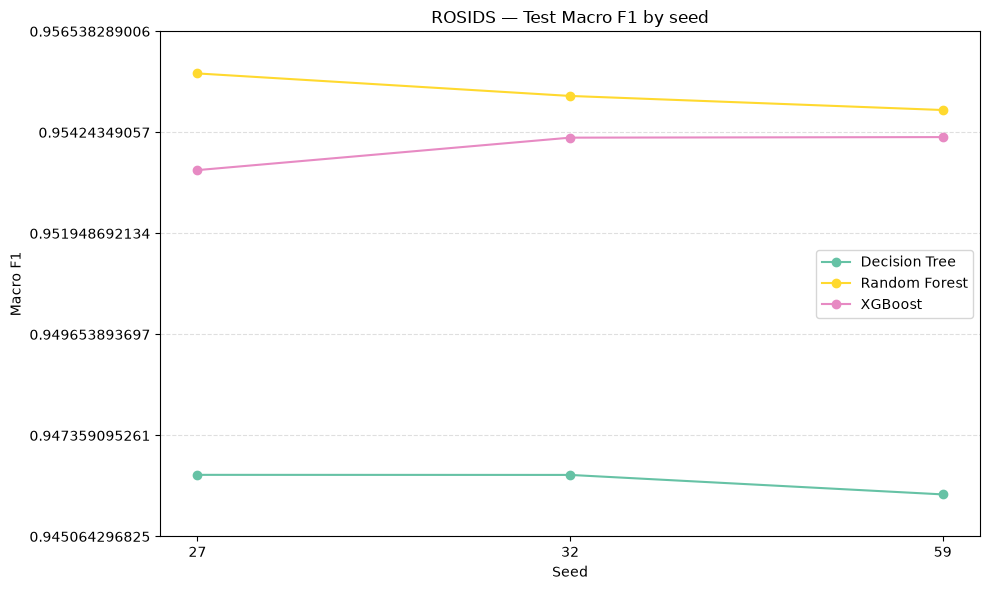

In [11]:
# ============================================================================
# Seed variability — primary test metric
# ============================================================================

seed_metric_plot_data = pd.concat(
    [
        artifacts_by_classifier[classifier_name].seed_metrics
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

figure = plot_test_seed_metric(
    seed_metrics=seed_metric_plot_data,
    metric=PRIMARY_TEST_METRIC,
    title=f"{DATASET_NAME} — Test {METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]} by seed",
)

display(figure)
plt.close(figure)


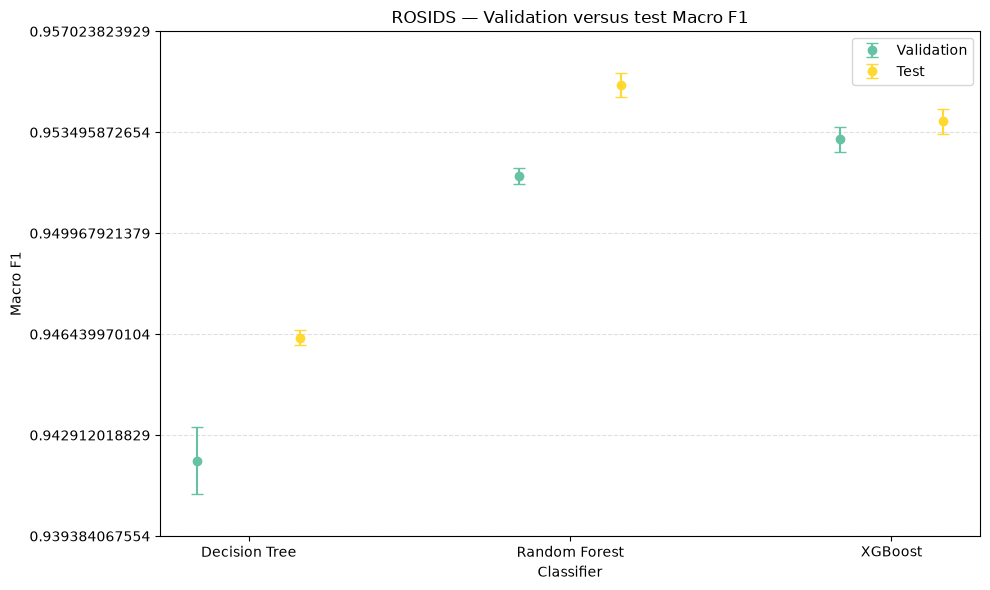

In [12]:
# ============================================================================
# Validation versus test — primary metric
# ============================================================================

if rosids_validation_vs_test is not None:
    macro_f1_comparison = rosids_validation_vs_test.loc[
        rosids_validation_vs_test["Metric"]
        == METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC],
        [
            "Classifier",
            "validation_mean",
            "validation_std",
            "test_mean",
            "test_std",
        ],
    ].copy()

    macro_f1_comparison = macro_f1_comparison.rename(
        columns={
            "Classifier": "classifier",
        },
    )

    figure = plot_metric_comparison(
        data_frame=macro_f1_comparison,
        metric=PRIMARY_TEST_METRIC,
        title=(
            f"{DATASET_NAME} — "
            f"Validation versus test {METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]}"
        ),
    )

    display(figure)
    plt.close(figure)


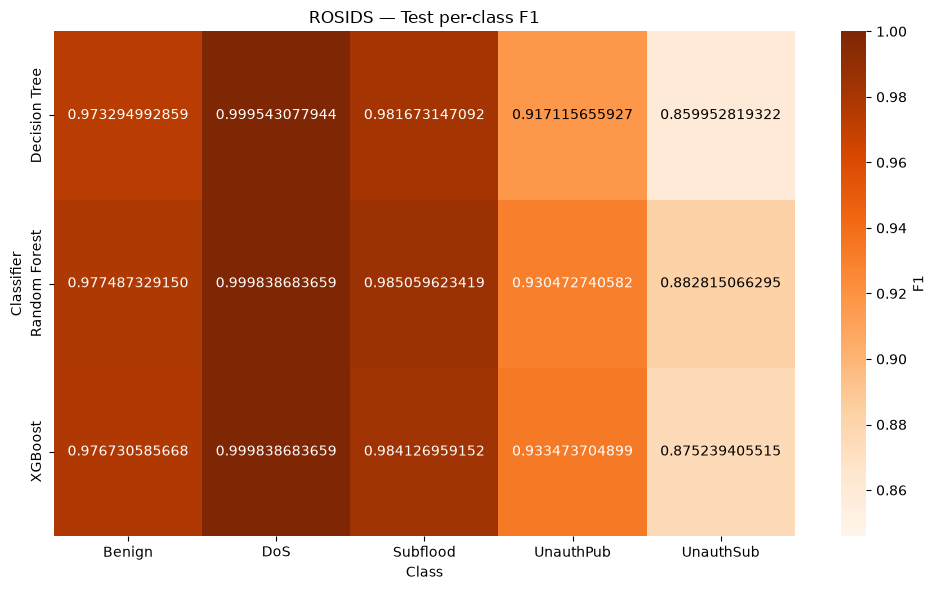

In [13]:
# ============================================================================
# Per-class F1 heatmap
# ============================================================================

per_class_plot_data = pd.concat(
    [
        artifacts_by_classifier[classifier_name].per_class_metrics
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

figure = plot_per_class_metric_heatmap(
    per_class_metrics=per_class_plot_data,
    metric="f1",
    title=f"{DATASET_NAME} — Test per-class F1",
)

display(figure)
plt.close(figure)


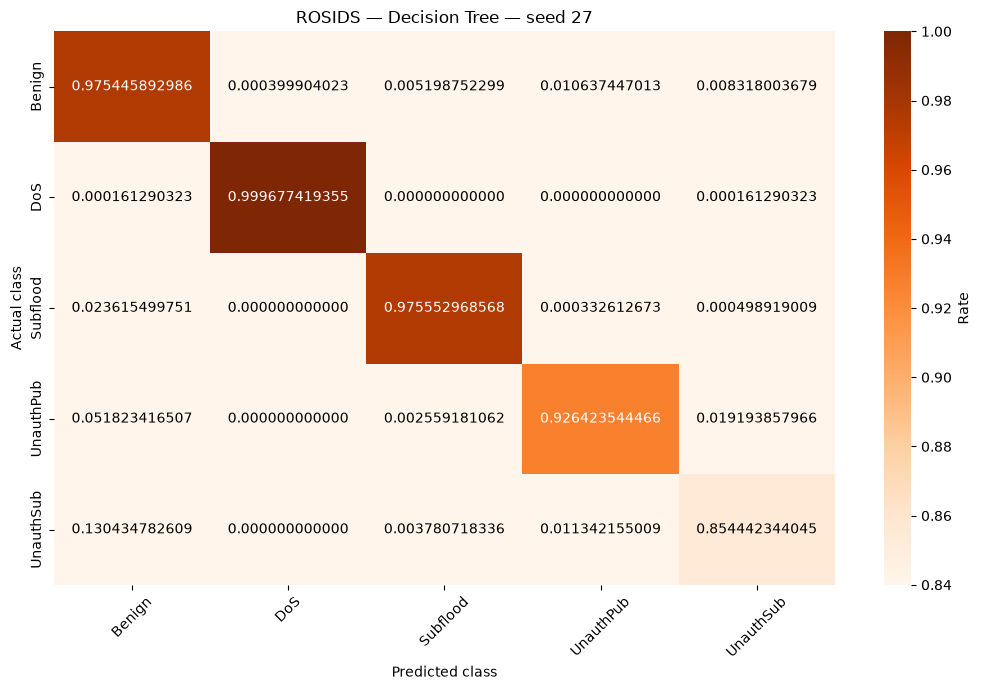

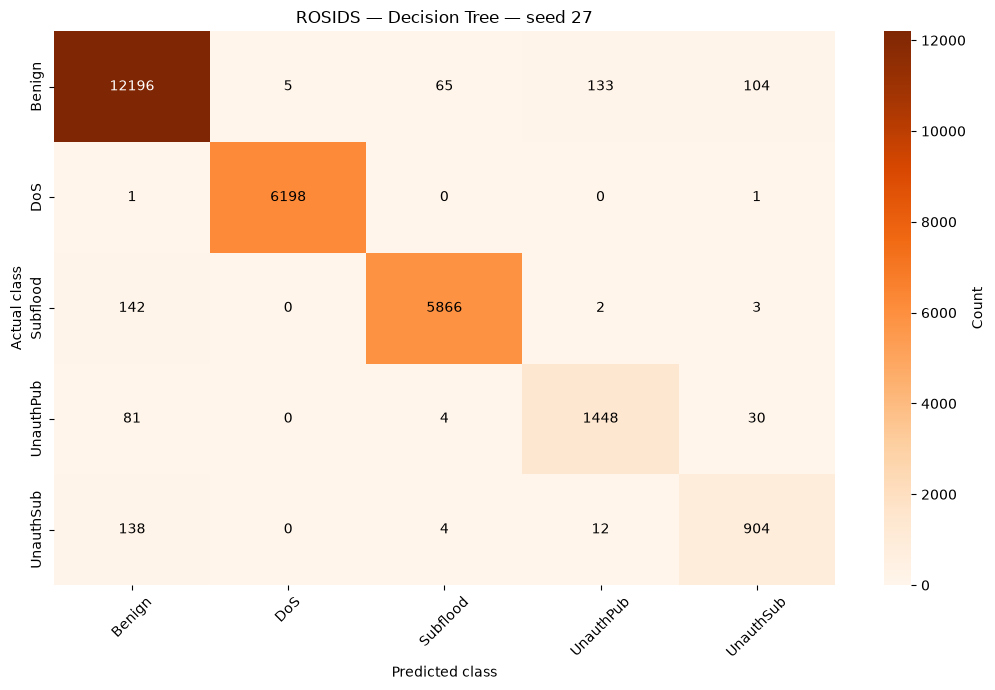

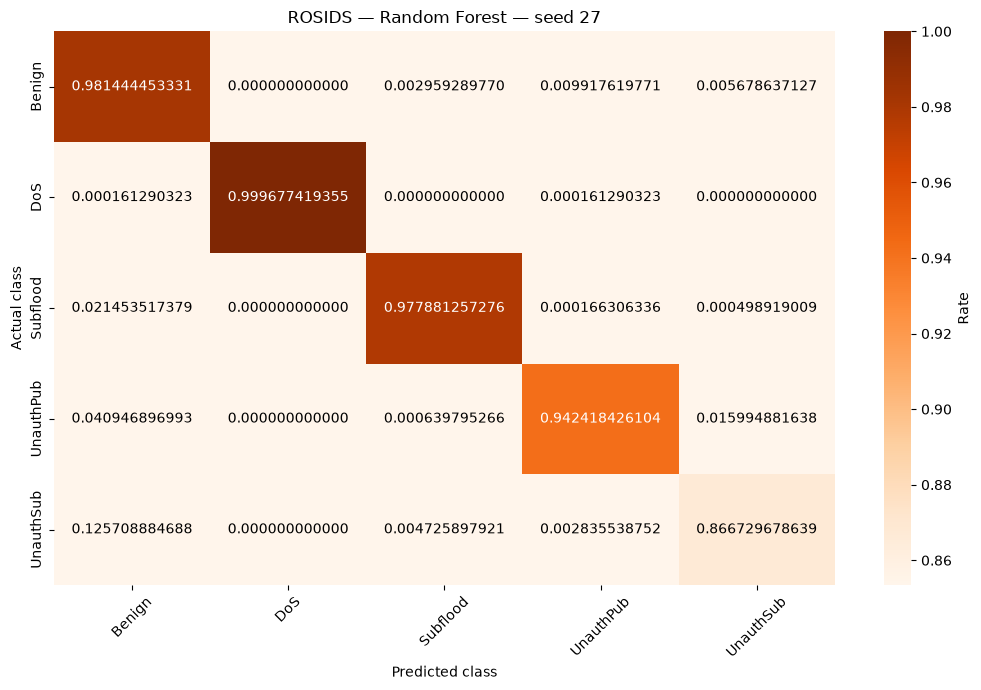

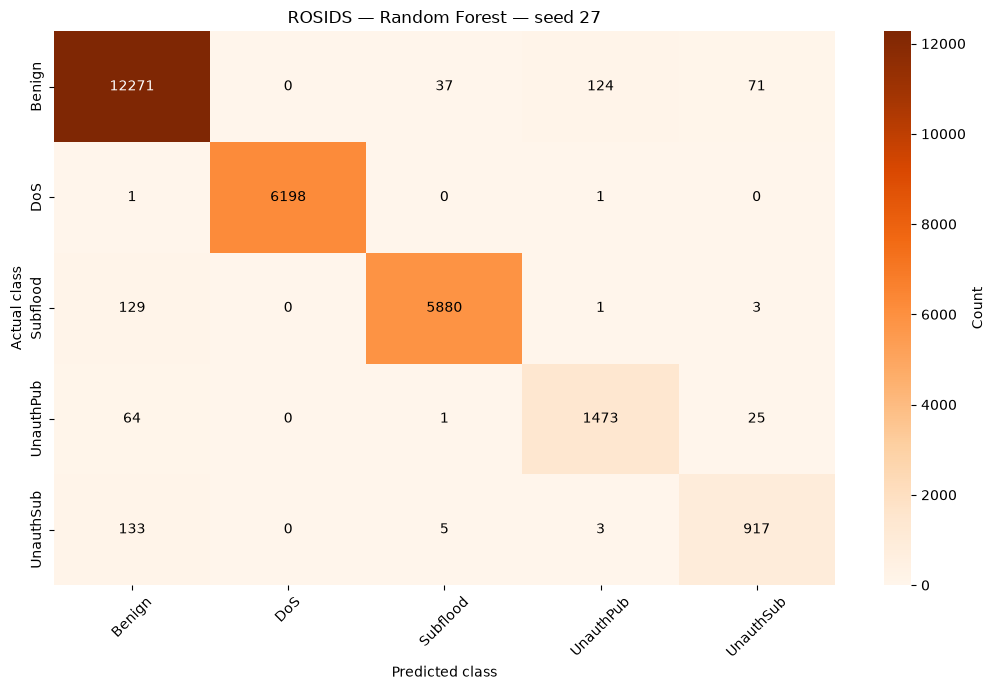

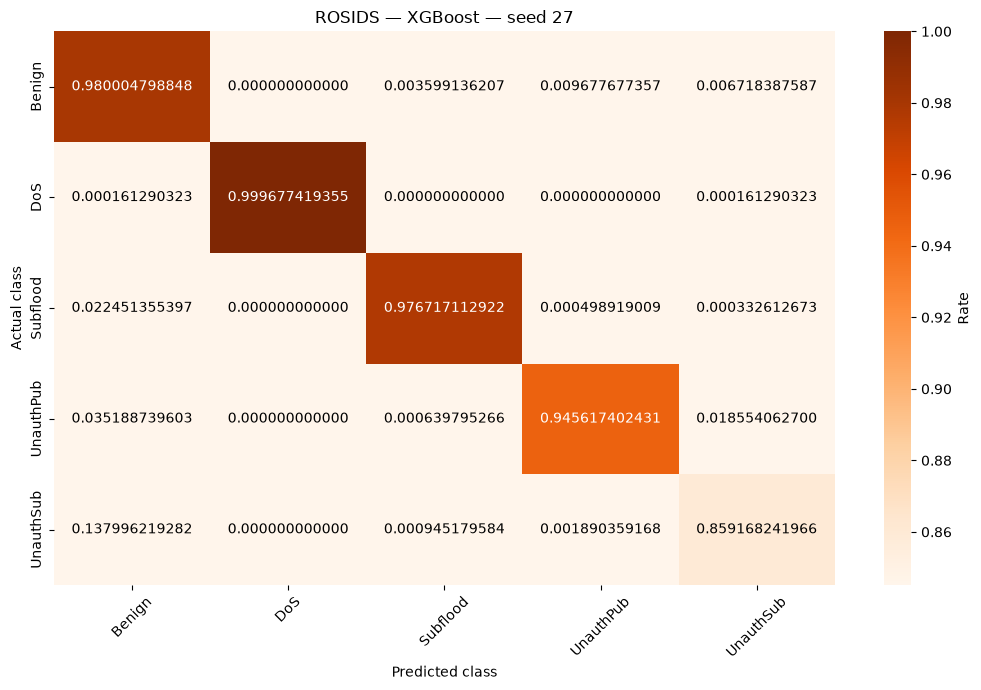

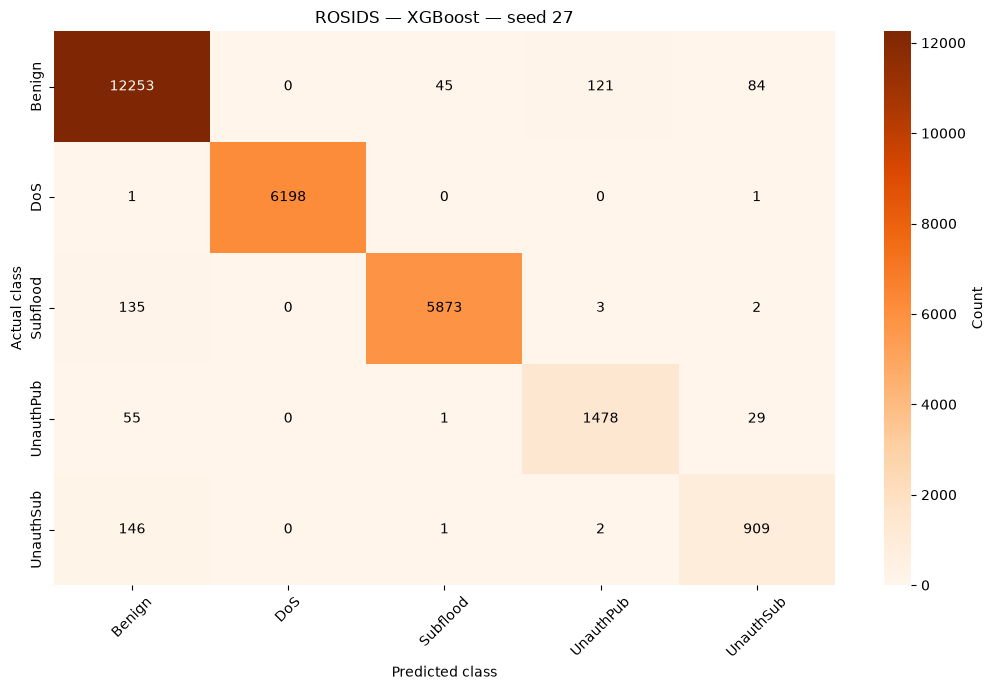

In [14]:
# ============================================================================
# Persisted confusion matrices
# ============================================================================

for classifier_name in CLASSIFIER_ORDER:
    experiment = artifacts_by_classifier[classifier_name]

    persisted_seeds = tuple(
        sorted(
            experiment.normalized_confusion_matrices,
        )
    )

    if not persisted_seeds:
        raise ValueError(
            f"No normalized confusion matrices were found for {classifier_name!r}.",
        )

    representative_seed = (
        REPRESENTATIVE_SEED if REPRESENTATIVE_SEED is not None else persisted_seeds[0]
    )

    display_test_confusion_matrices(
        experiment,
        normalized=True,
        seed=representative_seed,
    )

    display_test_confusion_matrices(
        experiment,
        normalized=False,
        seed=representative_seed,
    )


In [15]:
# ============================================================================
# Compact primary-metric table
# ============================================================================

primary_metric_column = METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]

rosids_primary_metric_summary = rosids_test_summary[
    [
        "Dataset",
        "Classifier",
        "Seeds",
        primary_metric_column,
    ]
].copy()

display(rosids_primary_metric_summary)

,Dataset,Classifier,Seeds,Macro F1
0,ROSIDS,Decision Tree,3,0.946315938629 ± 0.000255890723
1,ROSIDS,Random Forest,3,0.955134688621 ± 0.000419155610
2,ROSIDS,XGBoost,3,0.953881867779 ± 0.000429487849
